# Metodo de montecarlo

GIF guardado en: monte_carlo.gif


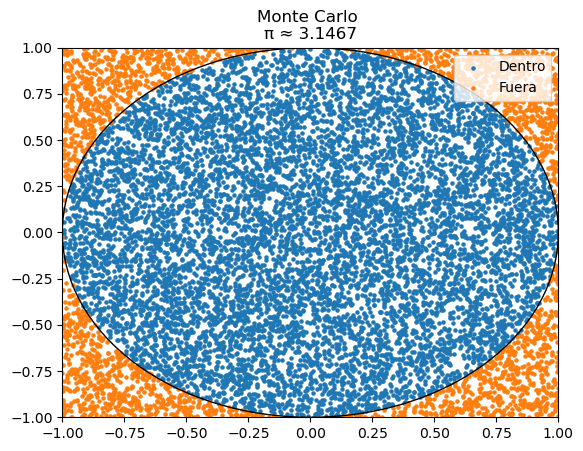

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

n_frames = 80              
points_per_frame = 150    

x_inside, y_inside = [], []
x_outside, y_outside = [],[]
fig, ax = plt.subplots()


def update(frame):
    global x_inside, y_inside, x_outside, y_outside
    
    
    x = np.random.uniform(-1, 1, points_per_frame)
    y = np.random.uniform(-1, 1, points_per_frame)
    
    dist2 = x**2 + y**2
    
    
    for i in range(points_per_frame):
        if dist2[i] <= 1:
            x_inside.append(x[i])
            y_inside.append(y[i])
        else:
            x_outside.append(x[i])
            y_outside.append(y[i])
    
    ax.clear()
    

    ax.scatter(x_inside, y_inside, s=5, label="Dentro")
    ax.scatter(x_outside, y_outside, s=5, label="Fuera")

    circle = plt.Circle((0, 0), 1, fill=False)
    ax.add_patch(circle)
    
    total = len(x_inside) + len(x_outside)
    pi_est = 4 * len(x_inside) / total if total > 0 else 0

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_title(f"Monte Carlo \nπ ≈ {pi_est:.4f}")
    ax.legend(loc="upper right")

ani = animation.FuncAnimation(
    fig, update, frames=n_frames, repeat=False
)

gif_path = "monte_carlo.gif"
ani.save(gif_path, writer="pillow", fps=5)

print(f"GIF guardado en: {gif_path}")

plt.show()

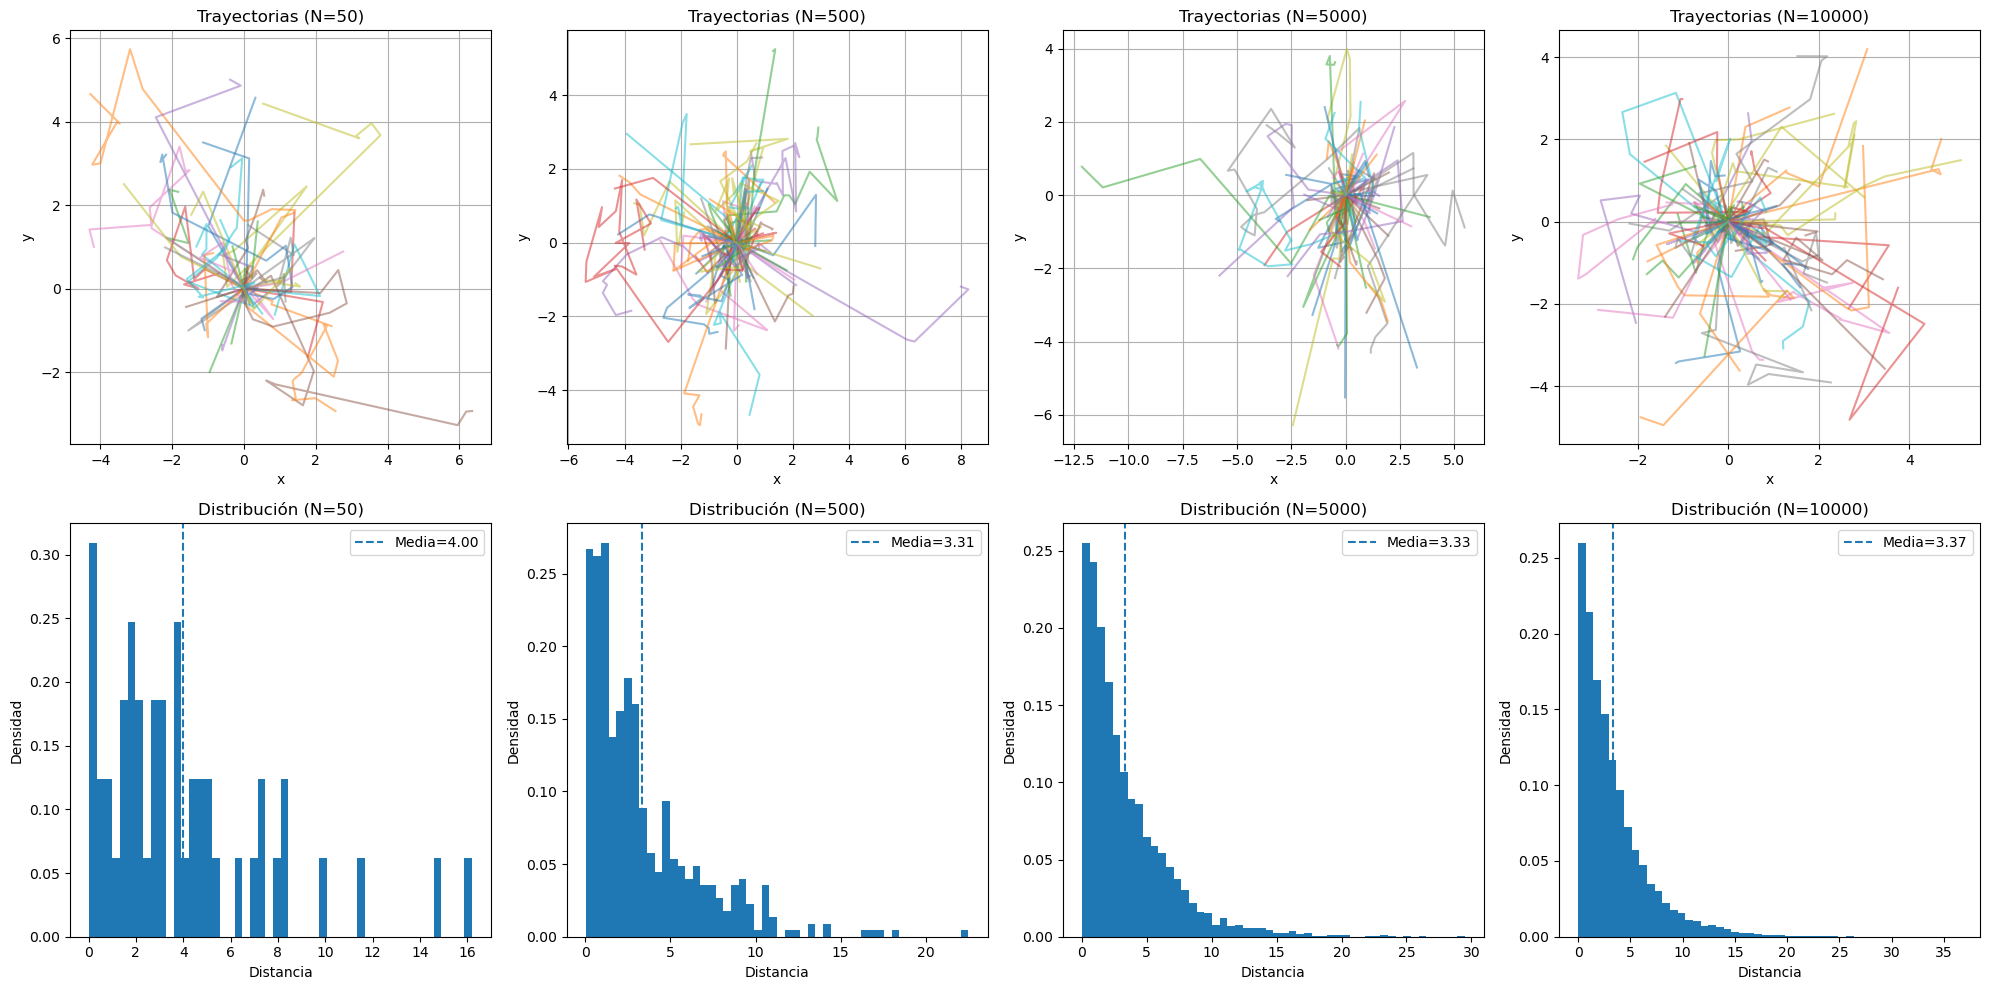

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Ns = [50, 500, 5000, 10000]
lambda_mean = 1.0
p_abs = 0.3


fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, N in enumerate(Ns):
    distancias = []
    trayectorias = []

    for _ in range(N):
        x, y = 0, 0
        distancia_total = 0
        trayectoria_x = [x]
        trayectoria_y = [y]

        while True:
            step = np.random.exponential(lambda_mean)
            theta = np.random.uniform(0, 2*np.pi)

            dx = step * np.cos(theta)
            dy = step * np.sin(theta)

            x += dx
            y += dy
            distancia_total += step

            trayectoria_x.append(x)
            trayectoria_y.append(y)

            if np.random.rand() < p_abs:
                break

        distancias.append(distancia_total)
        trayectorias.append((trayectoria_x, trayectoria_y))


    ax_traj = axes[0, col]
    
    max_plot = min(100, N)
    for i in range(max_plot):
        tx, ty = trayectorias[i]
        ax_traj.plot(tx, ty, alpha=0.5)

    ax_traj.set_title(f"Trayectorias (N={N})")
    ax_traj.set_xlabel("x")
    ax_traj.set_ylabel("y")
    ax_traj.grid()

    ax_hist = axes[1, col]
    ax_hist.hist(distancias, bins=50, density=True)

    ax_hist.set_title(f"Distribución (N={N})")
    ax_hist.set_xlabel("Distancia")
    ax_hist.set_ylabel("Densidad")
    media = np.mean(distancias)
    ax_hist.axvline(media, linestyle='--', label=f"Media={media:.2f}")
    ax_hist.legend()

plt.tight_layout()
plt.show()